# NavSight — what the app shows vs GPS (last ride)

1. **Trajectory** — the displayed dot path, coloured by time so the U-turn out-and-back is visible.
2. **Heading / U-turn timeline**.
3. **Dot position error** vs GPS.
4. **Speed** — IPM speedometer vs dot speed vs GPS.
5. **Distance over time** — cumulative distance (slope = speed).
6. **Accuracy by speed band** (bar graph).

*IPM vs dot speed are NOT the same:* **IPM** = the ground-plane speedometer the app shows; **dot speed** = how fast the displayed dot actually moved (it advances on the VIO on this pre-B build, so it differs).

In [1]:
import json, math, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SIM = 'tests/sims/val_2026_06_03b/simulation_data_1780505700912.json'
for cand in [SIM, os.path.join('..', SIM), os.path.abspath(SIM)]:
    if os.path.exists(cand):
        SIM = cand; break
with open(SIM, encoding='utf-8') as f:
    data = json.load(f)
df = pd.DataFrame(data['points'])
fm = data.get('frames_meta', {})
df['t'] = (df['ts'] - df['ts'].iloc[0]) / 1000.0
print(f'{os.path.basename(SIM)}: {len(df)} points, {df["t"].iloc[-1]:.0f}s, frames written={fm.get("written")} dropped={fm.get("dropped")}')

simulation_data_1780505700912.json: 3994 points, 257s, frames written=1601 dropped=2477


In [2]:
R = 6371000.0
def haversine_m(a, b, c, d):
    p1, p2 = math.radians(a), math.radians(c)
    dp = math.radians(c-a); dl = math.radians(d-b)
    h = math.sin(dp/2)**2 + math.cos(p1)*math.cos(p2)*math.sin(dl/2)**2
    return 2*R*math.asin(min(1.0, math.sqrt(h)))
def bearing_deg(a, b, c, d):
    y = math.sin(math.radians(d-b))*math.cos(math.radians(c))
    x = math.cos(math.radians(a))*math.sin(math.radians(c)) - math.sin(math.radians(a))*math.cos(math.radians(c))*math.cos(math.radians(d-b))
    return (math.degrees(math.atan2(y, x))+360) % 360
def adiff(a, b):
    return ((a-b+540) % 360) - 180
def track_speed(ts_ms, lat, lng, valid, min_m=0.05, gmax=5.0):
    out = np.full(len(ts_ms), np.nan); last = None
    for i in range(len(ts_ms)):
        if not valid[i]: continue
        if last is None: last = i; continue
        d = haversine_m(lat[last], lng[last], lat[i], lng[i])
        if d < min_m: continue
        dt = (ts_ms[i]-ts_ms[last])/1000.0
        if 0.2 < dt < gmax: out[i] = d/dt*3.6
        last = i
    return out
def cum_dist(ts_ms, lat, lng, valid, max_kmh=60.0):
    # Accumulate between DISTINCT fixes (keep `last` until the position actually moves), holding the
    # running total on the in-between frames. Advancing `last` every frame would divide a ~1 Hz fix
    # update by the ~0.06 s frame interval and the speed gate would wrongly reject it.
    out = np.full(len(ts_ms), np.nan); tot = 0.0; last = None
    for i in range(len(ts_ms)):
        if not valid[i]:
            if last is not None: out[i] = tot
            continue
        if last is None: last = i; out[i] = 0.0; continue
        d = haversine_m(lat[last], lng[last], lat[i], lng[i])
        if d < 0.05:
            out[i] = tot; continue
        dt = (ts_ms[i]-ts_ms[last])/1000.0
        if dt > 0 and d/dt*3.6 <= max_kmh: tot += d
        out[i] = tot; last = i
    return out
def ffill_hold(x, t, gap=2.5):
    out = np.full(len(x), np.nan); lv = np.nan; lt = -1e9
    for i in range(len(x)):
        if not np.isnan(x[i]): lv = x[i]; lt = t[i]
        if t[i]-lt <= gap: out[i] = lv
    return out
def smooth(x, t, tau=1.5):
    out = np.full(len(x), np.nan); s = np.nan; lt = None
    for i in range(len(x)):
        if np.isnan(x[i]): out[i] = s; lt = t[i]; continue
        if np.isnan(s) or lt is None: s = x[i]
        else: a = (t[i]-lt)/(tau+(t[i]-lt)); s = s + a*(x[i]-s)
        out[i] = s; lt = t[i]
    return out

In [3]:
ts = df['ts'].to_numpy(); t = df['t'].to_numpy()
def col(n):
    return df[n].to_numpy(dtype=float) if n in df.columns else np.full(len(df), np.nan)
glat, glng, gacc = col('glat'), col('glng'), col('gacc')
mmlat, mmlng = col('mm_lat'), col('mm_lng')
hdg = col('hdg')
ipm = col('gp_flow_speed')*3.6
gps_ok = (~np.isnan(glat)) & (~np.isnan(glng)) & ((np.isnan(gacc)) | (gacc <= 20.0))
mm_ok  = (~np.isnan(mmlat)) & (~np.isnan(mmlng))
gps_spd = ffill_hold(track_speed(ts, glat, glng, gps_ok), t)
dot_spd = ffill_hold(track_speed(ts, mmlat, mmlng, mm_ok), t)
gps_clean = np.where(gps_spd > 60.0, np.nan, gps_spd)

gbrg = np.full(len(df), np.nan); prev = None
for i in range(len(df)):
    if not gps_ok[i]: continue
    if prev is not None:
        d = haversine_m(glat[prev], glng[prev], glat[i], glng[i])
        if d > 1.0: gbrg[i] = bearing_deg(glat[prev], glng[prev], glat[i], glng[i]); prev = i
    else: prev = i
gbrg_h = ffill_hold(gbrg, t, gap=4.0)
uturns = []; WIN_S = 6.0
for i in range(len(df)):
    if np.isnan(gbrg_h[i]) or np.isnan(gps_clean[i]) or gps_clean[i] < 5: continue
    j = i
    while j > 0 and t[i]-t[j] < WIN_S: j -= 1
    if not np.isnan(gbrg_h[j]) and abs(adiff(gbrg_h[i], gbrg_h[j])) > 140:
        if not uturns or t[i]-t[uturns[-1]] > 8.0: uturns.append(i)
print(f'GPS median {np.nanmedian(gps_clean):.1f} km/h | U-turns detected: {len(uturns)} at t={[round(float(t[i])) for i in uturns]} s')

GPS median 27.7 km/h | U-turns detected: 1 at t=[133] s


## 1. Trajectory — dot path coloured by time

A U-turn doubles back on the **same** two-way road, so out and back overlap into one line. Colouring the dot by **time** (blue→red) makes the out-and-back visible: the road is traced once going out, then again in a later colour coming back. The black ★ is the U-turn; the grey band is GPS.

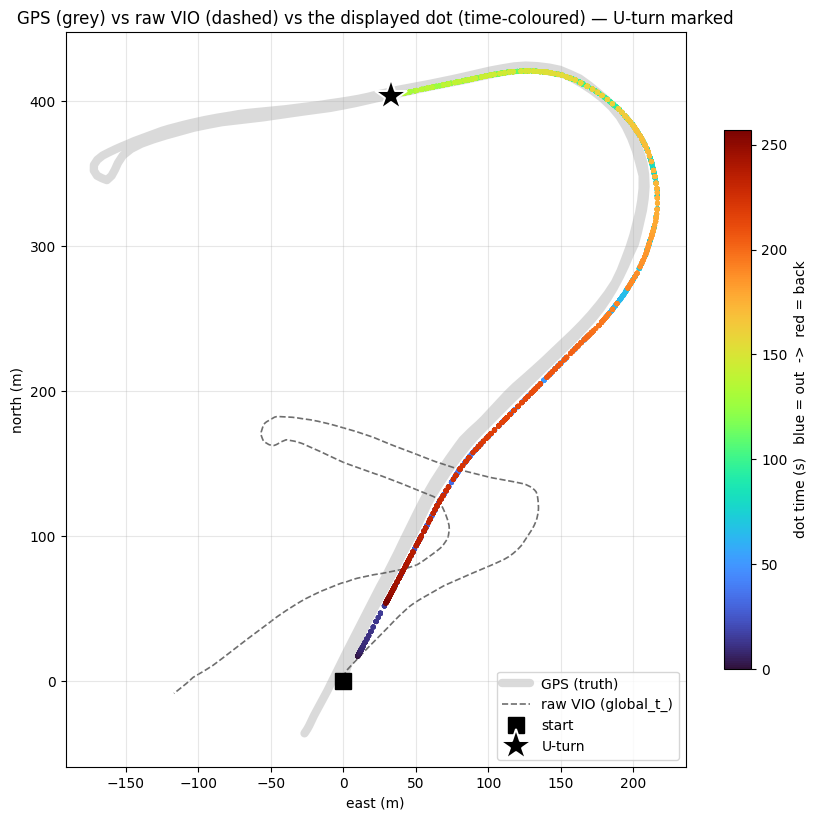

In [4]:
i0 = int(np.argmax(gps_ok)); lat0, lng0 = glat[i0], glng[i0]
ml = 111320.0; mn_ = 111320.0*math.cos(math.radians(lat0))
to_e = lambda lat, lng: ((lng-lng0)*mn_, (lat-lat0)*ml)
ge, gn = to_e(np.where(gps_ok, glat, np.nan), np.where(gps_ok, glng, np.nan))
me, mn = to_e(np.where(mm_ok, mmlat, np.nan), np.where(mm_ok, mmlng, np.nan))
vlat, vlng = col('vlat'), col('vlng')
vio_ok = (~np.isnan(vlat)) & (~np.isnan(vlng))
ve, vn = to_e(np.where(vio_ok, vlat, np.nan), np.where(vio_ok, vlng, np.nan))
fig, ax = plt.subplots(figsize=(10, 10))
ax.plot(ge, gn, color='#bdbdbd', lw=6, alpha=0.55, solid_capstyle='round', label='GPS (truth)', zorder=1)
ax.plot(ve, vn, color='#555', lw=1.2, ls='--', alpha=0.85, label='raw VIO (global_t_)', zorder=1.5)
v = mm_ok & ~np.isnan(me)
sc = ax.scatter(me[v], mn[v], c=t[v], cmap='turbo', s=7, zorder=2)
cb = fig.colorbar(sc, ax=ax, shrink=0.7); cb.set_label('dot time (s)   blue = out  ->  red = back')
ax.plot(ge[i0], gn[i0], 'ks', ms=11, label='start', zorder=3)
for k, i in enumerate(uturns):
    ax.plot(me[i], mn[i], '*', color='black', ms=24, mec='white', mew=1.4, label='U-turn' if k == 0 else None, zorder=4)
ax.set_xlabel('east (m)'); ax.set_ylabel('north (m)'); ax.set_aspect('equal')
ax.legend(loc='best'); ax.grid(alpha=0.3)
ax.set_title('GPS (grey) vs raw VIO (dashed) vs the displayed dot (time-coloured) — U-turn marked')
plt.show()

## 2. Heading / U-turn timeline

GPS travel bearing (green) vs the app heading `hdg` (blue) over time. A **U-turn = a ~180° flip** (purple line). If blue flips with green there, the app caught it.

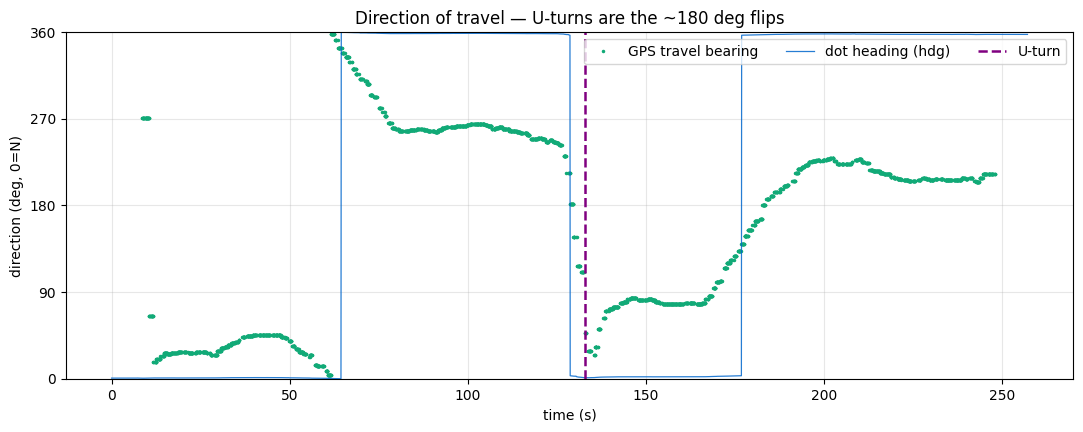

In [5]:
fig, ax = plt.subplots(figsize=(13, 4.5))
ax.plot(t, gbrg_h, '.', color='#1a7', ms=3, label='GPS travel bearing')
ax.plot(t, np.where(np.isnan(hdg), np.nan, hdg % 360), '-', color='#06c', lw=0.9, alpha=0.85, label='dot heading (hdg)')
for k, i in enumerate(uturns):
    ax.axvline(t[i], color='purple', lw=1.8, ls='--', label='U-turn' if k == 0 else None)
ax.set_xlabel('time (s)'); ax.set_ylabel('direction (deg, 0=N)'); ax.set_ylim(0, 360)
ax.set_yticks([0, 90, 180, 270, 360]); ax.legend(ncol=3); ax.grid(alpha=0.3)
ax.set_title('Direction of travel — U-turns are the ~180 deg flips')
plt.show()
if not uturns:
    print('No >140 deg flip auto-detected — lower WIN_S / the 140 threshold in the parse cell if the U-turn was gradual.')

## 3. Dot position error vs GPS

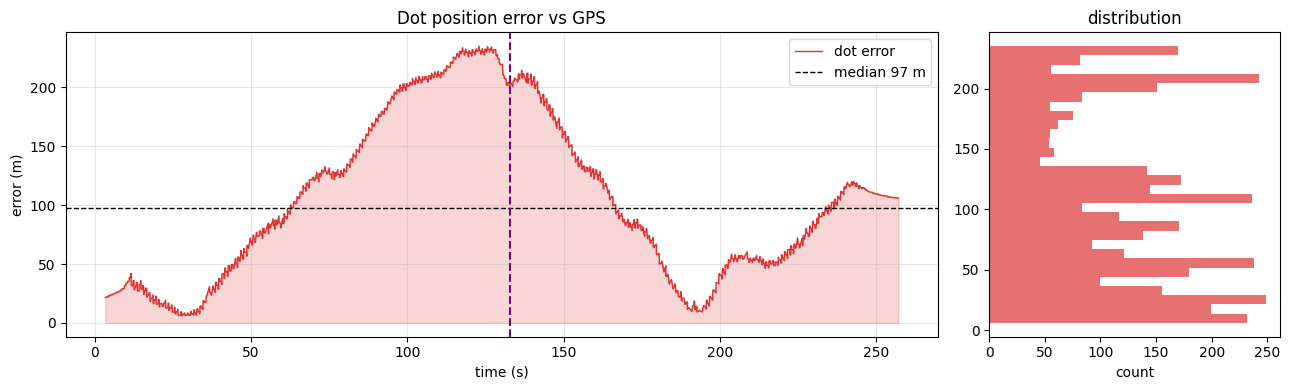

dot error: median 97 m, p90 209 m, max 235 m


In [6]:
dot_err = np.full(len(df), np.nan)
for i in range(len(df)):
    if gps_ok[i] and mm_ok[i]: dot_err[i] = haversine_m(glat[i], glng[i], mmlat[i], mmlng[i])
e = dot_err[~np.isnan(dot_err)]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4), gridspec_kw={'width_ratios': [3, 1]})
ax1.fill_between(t, 0, dot_err, color='#d33', alpha=0.2)
ax1.plot(t, dot_err, color='#d33', lw=1.0, label='dot error')
ax1.axhline(np.median(e), color='k', ls='--', lw=1, label=f'median {np.median(e):.0f} m')
for i in uturns: ax1.axvline(t[i], color='purple', lw=1.5, ls='--')
ax1.set_xlabel('time (s)'); ax1.set_ylabel('error (m)'); ax1.legend(); ax1.grid(alpha=0.3)
ax1.set_title('Dot position error vs GPS')
ax2.hist(e, bins=30, color='#d33', alpha=0.7, orientation='horizontal')
ax2.set_xlabel('count'); ax2.set_title('distribution')
plt.tight_layout(); plt.show()
print(f'dot error: median {np.median(e):.0f} m, p90 {np.percentile(e,90):.0f} m, max {np.max(e):.0f} m')

## 4. Speed — IPM speedometer vs dot speed vs GPS

**GPS** (green) is truth. **IPM** (blue) is the speedometer the app shows (smoothed). **dot speed** (orange) is how fast the displayed dot moved. If IPM stays low/flat while GPS climbs → it's under-reading.

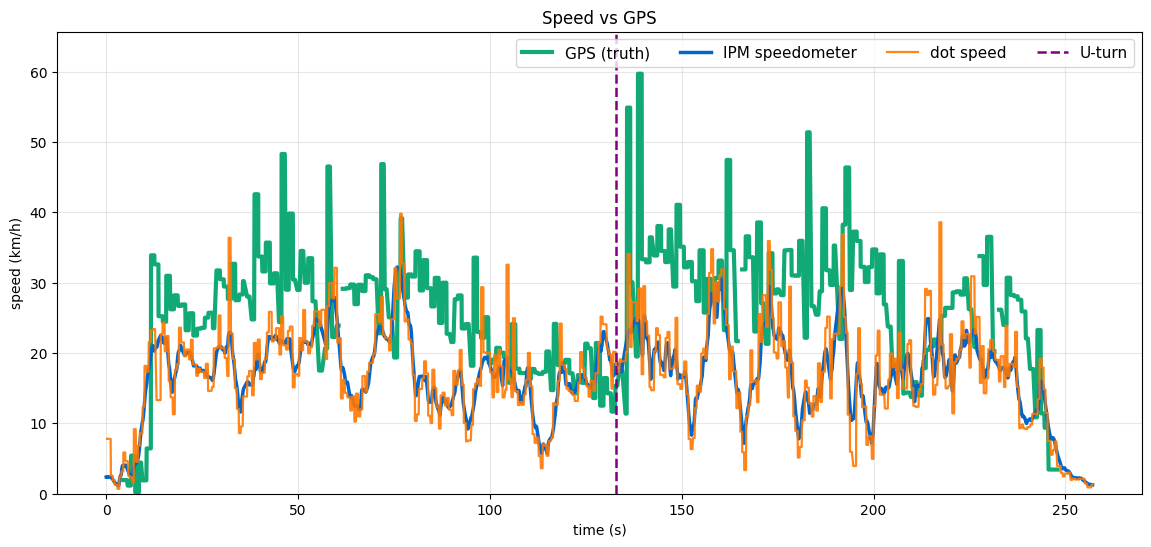

In [7]:
ipm_s = smooth(ipm, t)
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(t, gps_clean, color='#1a7', lw=3.0, label='GPS (truth)')
ax.plot(t, ipm_s, color='#06c', lw=2.5, label='IPM speedometer')
ax.plot(t, dot_spd, color='#f70', lw=1.6, alpha=0.9, label='dot speed')
for k, i in enumerate(uturns):
    ax.axvline(t[i], color='purple', lw=1.8, ls='--', label='U-turn' if k == 0 else None)
ax.set_xlabel('time (s)'); ax.set_ylabel('speed (km/h)')
ax.set_ylim(0, max(60, np.nanmax(gps_clean)*1.1))
ax.legend(ncol=4, fontsize=11); ax.grid(alpha=0.3); ax.set_title('Speed vs GPS')
plt.show()

## 5. Distance over time — GPS vs the dot

Cumulative distance travelled. **The slope is the speed.** Where the red (dot) line falls below green (GPS), the dot is under-travelling — the shaded gap is the shortfall.

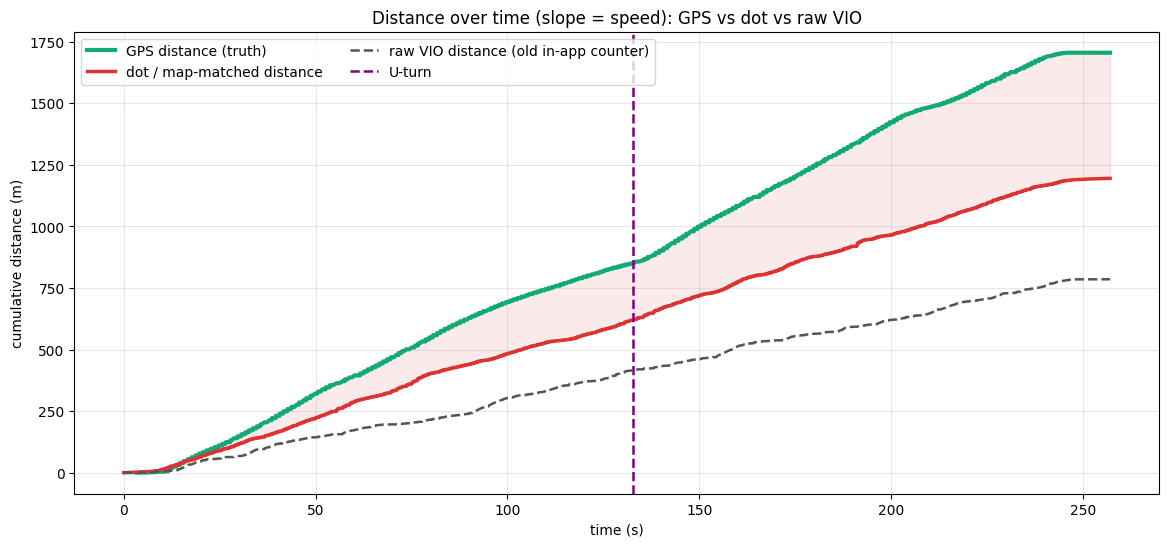

Total GPS 1705 m  |  dot/map-matched 1195 m (0.70x)  |  raw VIO 785 m (0.46x)
--> the MAP-MATCHED (dot) trajectory distance is the dot/map-matched value above; the raw VIO is the old in-app counter.


In [8]:
gps_cd = cum_dist(ts, glat, glng, gps_ok)
dot_cd = cum_dist(ts, mmlat, mmlng, mm_ok)
# raw VIO cumulative distance from the VIO local frame (vx,vz) = exactly what the in-app counter summed.
vx = col('vx'); vz = col('vz')
vio_cd = np.full(len(df), np.nan); tot = 0.0; pv = None
for i in range(len(df)):
    if np.isnan(vx[i]) or np.isnan(vz[i]):
        if pv is not None: vio_cd[i] = tot
        continue
    if pv is None: pv = i; vio_cd[i] = 0.0; continue
    tot += math.hypot(vx[i]-vx[pv], vz[i]-vz[pv]); vio_cd[i] = tot; pv = i
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(t, gps_cd, color='#1a7', lw=3.0, label='GPS distance (truth)')
ax.plot(t, dot_cd, color='#d33', lw=2.5, label='dot / map-matched distance')
ax.plot(t, vio_cd, color='#555', lw=1.8, ls='--', label='raw VIO distance (old in-app counter)')
ax.fill_between(t, dot_cd, gps_cd, where=~np.isnan(gps_cd), color='#d33', alpha=0.10)
for k, i in enumerate(uturns):
    ax.axvline(t[i], color='purple', lw=1.8, ls='--', label='U-turn' if k == 0 else None)
ax.set_xlabel('time (s)'); ax.set_ylabel('cumulative distance (m)')
ax.legend(ncol=2); ax.grid(alpha=0.3); ax.set_title('Distance over time (slope = speed): GPS vs dot vs raw VIO')
plt.show()
gtot = np.nanmax(gps_cd); dtot = np.nanmax(dot_cd); vtot = np.nanmax(vio_cd)
print(f'Total GPS {gtot:.0f} m  |  dot/map-matched {dtot:.0f} m ({dtot/gtot:.2f}x)  |  raw VIO {vtot:.0f} m ({vtot/gtot:.2f}x)')
print('--> the MAP-MATCHED (dot) trajectory distance is the dot/map-matched value above; the raw VIO is the old in-app counter.')

## 6. Accuracy by speed band (does it track, or saturate?)

At each true GPS speed band, median GPS vs IPM vs dot speed. Flat IPM/dot bars while the GPS bar climbs = saturation.

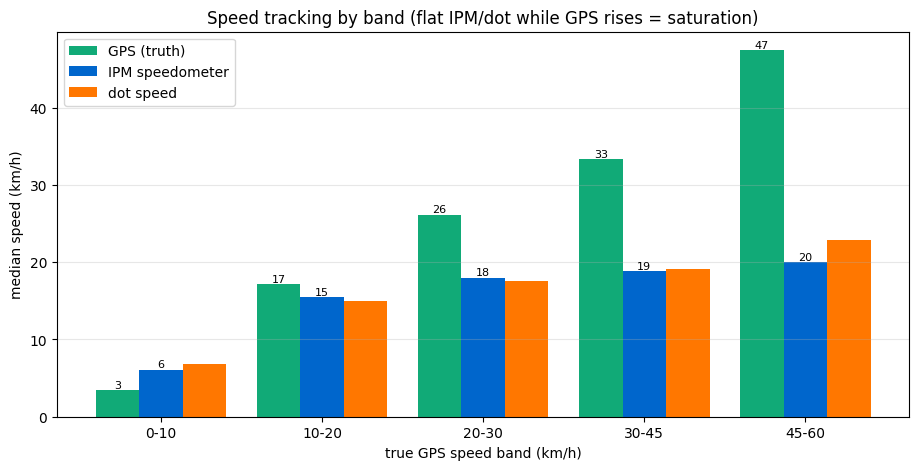

In [9]:
bands = [(0,10),(10,20),(20,30),(30,45),(45,60)]
labels, g_, i_, d_ = [], [], [], []
for lo,hi in bands:
    m = (~np.isnan(gps_clean)) & (gps_clean>=lo) & (gps_clean<hi)
    if m.sum() < 5: continue
    labels.append(f'{lo}-{hi}'); g_.append(np.nanmedian(gps_clean[m]))
    i_.append(np.nanmedian(ipm[m])); d_.append(np.nanmedian(dot_spd[m]))
x = np.arange(len(labels)); w = 0.27
fig, ax = plt.subplots(figsize=(11, 5))
b1 = ax.bar(x-w, g_, w, color='#1a7', label='GPS (truth)')
b2 = ax.bar(x,   i_, w, color='#06c', label='IPM speedometer')
b3 = ax.bar(x+w, d_, w, color='#f70', label='dot speed')
ax.bar_label(b1, fmt='%.0f', fontsize=8); ax.bar_label(b2, fmt='%.0f', fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(labels); ax.set_xlabel('true GPS speed band (km/h)')
ax.set_ylabel('median speed (km/h)'); ax.legend(); ax.grid(alpha=0.3, axis='y')
ax.set_title('Speed tracking by band (flat IPM/dot while GPS rises = saturation)')
plt.show()

In [10]:
def metrics(name, ch):
    mov = (~np.isnan(gps_clean)) & (gps_clean>=5.0) & (~np.isnan(ch)); g, c = gps_clean[mov], ch[mov]
    if len(g) < 5: return dict(channel=name, n=int(len(g)))
    return dict(channel=name, n=int(len(g)), median_kmh=round(float(np.median(c)),1),
                ratio=round(float(np.median(c/g)),2), MAE=round(float(np.mean(np.abs(c-g))),1),
                corr=round(float(np.corrcoef(g,c)[0,1]),2), freeze_pct=round(float(100*np.mean(c<1.1)),0))
pd.DataFrame([metrics('IPM speedometer', ipm), metrics('dot speed', dot_spd)])

,channel,n,median_kmh,ratio,MAE,corr,freeze_pct
0,IPM speedometer,3627,17.6,0.67,11.6,0.11,0.0
1,dot speed,3627,17.6,0.66,10.9,0.20,0.0


## Takeaways

- **U-turn** (1 & 2): the time-coloured path shows the road traced out then back; the heading should flip ~180° at the purple mark.
- **Speed** (4 & 6): IPM/dot flat while GPS climbs = saturated. When IPM climbs with GPS, the speed fix works.
- **Distance** (5): the gap is the dot under-travelling — 0.70× on this ride.

Edit `SIM` in the first code cell for a newer recording.